# Man-Woman Classification

In [2]:
import keras
keras.__version__

'3.14.1'

In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [47]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.utils import image_dataset_from_directory
from keras.applications import MobileNetV3Small
from keras.applications.mobilenet_v3 import preprocess_input
from keras import Model, layers, callbacks, Sequential, optimizers

## 1- Load and Prepare the Dataset

In [39]:
DATASET_DIR = 'data'
IMAGE_SHAPE = (150, 150, 3)

In [6]:
train_files_men = glob.glob(f'{DATASET_DIR}/train/men/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')
train_files_women = glob.glob(f'{DATASET_DIR}/train/women/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')

valid_files_men = glob.glob(f'{DATASET_DIR}/valid/men/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')
valid_files_women = glob.glob(f'{DATASET_DIR}/valid/women/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')

test_files_men = glob.glob(f'{DATASET_DIR}/test/men/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')
test_files_women = glob.glob(f'{DATASET_DIR}/test/women/*.*g') + glob.glob(f'{DATASET_DIR}/train/men/*.gif')

In [7]:
print(f'Men (train): {len(train_files_men)} | Women (train): {len(train_files_women)}')
print(f'Men (val): {len(valid_files_men)} | Women (val): {len(valid_files_women)}')
print(f'Men (test): {len(test_files_men)} | Women (test): {len(test_files_women)}')

Men (train): 789 | Women (train): 987
Men (val): 185 | Women (val): 188
Men (test): 420 | Women (test): 424


In [9]:
print('Train Dataset:')
train_dataset = image_dataset_from_directory(
    f'{DATASET_DIR}/train',
    image_size=IMAGE_SHAPE[:-1],
    batch_size=32,
    label_mode='binary'
)
print('Validation Dataset:')
val_dataset = image_dataset_from_directory(
    f'{DATASET_DIR}/valid',
    image_size=IMAGE_SHAPE[:-1],
    batch_size=32,
    label_mode='binary'
)
print('Test Dataset:')
test_dataset = image_dataset_from_directory(
    f'{DATASET_DIR}/test',
    image_size=IMAGE_SHAPE[:-1],
    batch_size=32,
    label_mode='binary'
)

Train Dataset:
Found 1800 files belonging to 2 classes.
Validation Dataset:
Found 372 files belonging to 2 classes.
Test Dataset:
Found 848 files belonging to 2 classes.


Data batch shape: (32, 150, 150, 3)
Label batch shape: (32, 1)


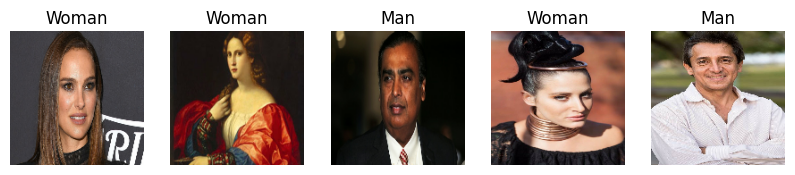

In [19]:
for data_batch, label_batch in train_dataset:
    print('Data batch shape:', data_batch.shape)
    print('Label batch shape:', label_batch.shape)
    
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
    for i in range(5):
        axes[i].imshow(data_batch[i].numpy().astype('uint8'))
        axes[i].axis('off')
        title = 'Man' if label_batch[i].numpy() == 0 else 'Woman'
        axes[i].set_title(title)
    break

## 2- Model Design

### Load a pre-trained model

In [21]:
conv_base = MobileNetV3Small(weights='imagenet', input_shape=IMAGE_SHAPE)

In [22]:
conv_base_no_top = Model(inputs=conv_base.input, 
                         outputs=conv_base.layers[-8].output)

In [23]:
conv_base_no_top.layers[-1].output.shape

(None, 5, 5, 576)

### Feature Extraction + MLP

In [24]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocess_input(images)
        features = conv_base_no_top.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

In [ ]:
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(val_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [26]:
print('Train Features:', train_features.shape)
print('Validation Features:', val_features.shape)
print('Test Features:', test_features.shape)

Train Features: (1800, 5, 5, 576)
Validation Features: (372, 5, 5, 576)
Test Features: (848, 5, 5, 576)


In [29]:
inp = layers.Input(shape=train_features.shape[1:])
x = layers.GlobalAveragePooling2D()(inp)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1, activation='sigmoid')(x)
model = Model(inputs=inp, outputs=out)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 5, 5, 576)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
my_callbacks = [
    callbacks.ModelCheckpoint('feature_extraction.keras',
                              save_best_only=True,
                              monitor='val_loss'
                             ),
    callbacks.TensorBoard(log_dir='logs')
]

In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [32]:
history = model.fit(train_features, train_labels,
                    batch_size=32,
                    epochs=20,
                    validation_data=(val_features, val_labels),
                    callbacks=my_callbacks)

Epoch 1/20


I0000 00:00:1781191813.809890  201376 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18735__.10


50/57 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6298 - loss: 0.6492

I0000 00:00:1781191815.521589  201373 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18735__.10


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6911 - loss: 0.5745 - val_accuracy: 0.7742 - val_loss: 0.4806
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8139 - loss: 0.4150 - val_accuracy: 0.8199 - val_loss: 0.4279
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8361 - loss: 0.3700 - val_accuracy: 0.7957 - val_loss: 0.4427
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8578 - loss: 0.3329 - val_accuracy: 0.7957 - val_loss: 0.4275
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8661 - loss: 0.3103 - val_accuracy: 0.8011 - val_loss: 0.4392
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8817 - loss: 0.2837 - val_accuracy: 0.7930 - val_loss: 0.4206
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8889 - loss: 0.2686 - val_accuracy: 0.7876 - val_loss: 0.4332
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8933 - loss: 0.2498 - val_accuracy: 0.8118 - val_loss: 0.4312
E

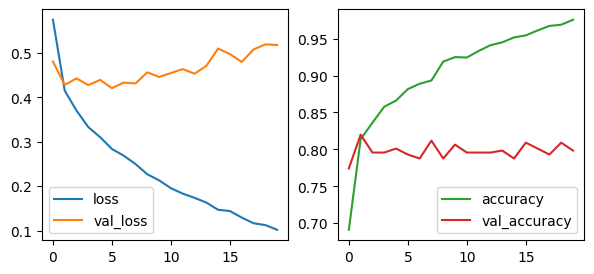

In [33]:
history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    figsize=(7, 3),
    subplots=(('loss', 'val_loss'), ('accuracy', 'val_accuracy')),
    layout=(1, 2)
)
plt.show()

In [34]:
loss, acc = model.evaluate(test_features, test_labels, verbose=0)
print(f'Test accuracy: {acc*100:.2f}')

Test accuracy: 90.09


### Data Augmentation + Feature Extraction + MLP

In [36]:
augmentation_model = Sequential([
    layers.RandomFlip('Horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
])

In [38]:
conv_base_no_top.trainable = False

In [48]:
inp = layers.Input(shape=IMAGE_SHAPE)
x = augmentation_model(inp)
x = preprocess_input(x)
x = conv_base_no_top(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.1)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model2 = Model(inputs=inp, outputs=out)
model2.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 5, 5, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 957,617 (3.65 MB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [49]:
model2.compile(optimizer=optimizers.Adam(learning_rate=0.5*0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [50]:
history2 = model2.fit(train_dataset,
                      batch_size=32,
                      epochs=30,
                      validation_data=(val_dataset),
                      callbacks=my_callbacks)

Epoch 1/30
17/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5517 - loss: 0.7068

W0000 00:00:1781192771.517914  214050 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1781192771.585184  214041 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


21/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5554 - loss: 0.7042

W0000 00:00:1781192771.846107  214050 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1781192771.880739  214039 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5631 - loss: 0.6967

...

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8779 - loss: 0.3060

W0000 00:00:1781192859.986453  216842 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


55/57 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8794 - loss: 0.3025

Corrupt JPEG data: 5 extraneous bytes before marker 0xee


57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8867 - loss: 0.2875 - val_accuracy: 0.7984 - val_loss: 0.4296


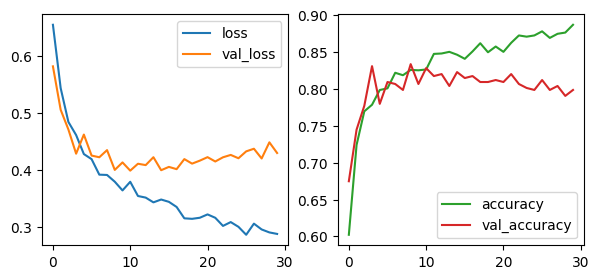

In [51]:
history_df2 = pd.DataFrame(history2.history)
history_df2[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    figsize=(7, 3),
    subplots=(('loss', 'val_loss'), ('accuracy', 'val_accuracy')),
    layout=(1, 2)
)
plt.show()

In [52]:
loss, acc = model2.evaluate(test_dataset, verbose=0)
print(f'Test accuracy: {acc*100:.2f}')

W0000 00:00:1781192943.040120  216963 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1781192943.194161  216951 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
W0000 00:00:1781192943.295898  216954 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


Test accuracy: 84.32


## 3- Deployment

In [58]:
from glob import glob
import matplotlib.pyplot as plt
from keras.saving import load_model
from keras.utils import load_img, img_to_array

In [54]:
best_model = load_model('feature_extraction.keras')

In [59]:
image_paths = glob('images/*.*g')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


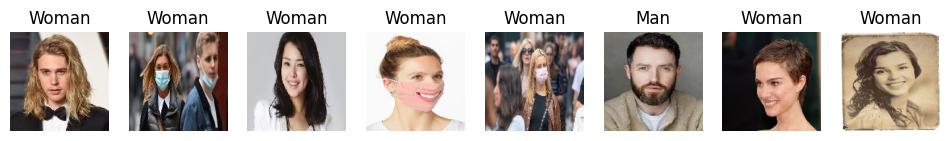

In [64]:
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(len(axes)):
    img = load_img(image_paths[i], target_size=(150, 150))
    img_arr = img_to_array(img).astype('uint8')
    img_arr = np.expand_dims(img_arr, axis=0)
    pred = best_model.predict(img_arr)
    label = 'Man' if pred<0.3 else 'Woman'
    axes[i].imshow(img)
    axes[i].set_axis_off()
    axes[i].set_title(label)
plt.show()